In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from codes import OpticalData, Styles

Styles.set_styles()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
optical = OpticalData(ew_filepath="../data/optical/EW_Ridgecrest_1m_utm_detrended.tif", ns_filepath="../data/optical/NS_Ridgecrest_1m_utm_detrended.tif")
optical = optical.decimate(10)

Init OpticalData with {'ew_filepath': '../data/optical/EW_Ridgecrest_1m_utm_detrended.tif', 'ns_filepath': '../data/optical/NS_Ridgecrest_1m_utm_detrended.tif'}
Importing TIF files: ../data/optical/EW_Ridgecrest_1m_utm_detrended.tif ../data/optical/NS_Ridgecrest_1m_utm_detrended.tif
Imported EW data shape: (53626, 48648)
Imported NS data shape: (53626, 48648)

Decimating EW optical...
Decimating NS optical...
Decimated



In [5]:
# ---- Fault: merge the two Little Lake strands into one TDE fault ----
from codes import FaultTriangles
import os
FAULT_DIR = "../data/fault"
FAULT_NPZ = [
    "SNFA-LLFZ-EAST-Eastern_Little_Lake_main_fault-CFM5_remesh.npz",
    "SNFA-LLFZ-SOUT-Southern_Little_Lake_main_fault-CFM5_remesh.npz",
]
strands = [FaultTriangles.from_npz(os.path.join(FAULT_DIR, f))
            for f in FAULT_NPZ]
fault = FaultTriangles.merge(strands, name="LLFZ")
print(f"[fault] {fault} | patches per strand: "
        f"{[len(v) for v in fault.patch_areas_by_fault().values()]}")

[fault] FaultTriangles(name='LLFZ', 568 triangles, 344 vertices, datum=542.4 m) | patches per strand: [284, 284]


Plotting...
... plotted.


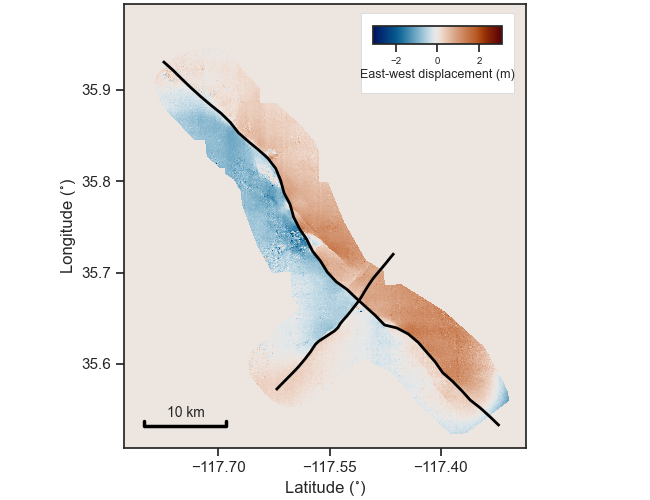

In [10]:
fig, ax = optical.plot_ew(fault=fault)

fig.savefig("../fig/optical_ew_ridgecrest.png", dpi=300, bbox_inches="tight")
# ax.set_ylim(35.75, 35.8)
# ax.set_xlim(-117.625, -117.585)